In [1]:
!pip install trl

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import polars as pl
import torch
from tqdm.auto import tqdm, trange

from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertModel, AutoModelForCausalLM, TrainingArguments, AutoModel
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader
from datasets import Dataset
from datasets import concatenate_datasets

import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import AdamW

import json
import random

from peft import LoraConfig, PeftModel
from trl import SFTTrainer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
RANDOM_STATE=42

# Анализ датасетов

## RuATD

Paper: https://arxiv.org/pdf/2206.01583

Higging Face: https://huggingface.co/datasets/RussianNLP/coat/viewer/binary/test

1 - Machine-generated, 0 - Human-written

In [2]:
splits = {'train': 'binary/train-00000-of-00001.parquet', 'validation': 'binary/validation-00000-of-00001.parquet', 'test': 'binary/test-00000-of-00001.parquet'}

df_ruatd_train = pl.read_parquet("hf://datasets/RussianNLP/coat/" + splits["train"])
df_ruatd_val = pl.read_parquet("hf://datasets/RussianNLP/coat/" + splits["validation"])

In [54]:
print(f"Train df length: {df_ruatd_train.shape[0]}")
print(f"Validation df length: {df_ruatd_val.shape[0]}")

Train df length: 172398
Validation df length: 24628


In [ ]:
# 1 - Machine-generated, 0 - Human-written
df_ruatd_train.head()

id,text,label
i64,str,i64
0,"""Отношения Гапона с эсерами так…",0
1,"""В 1756 году его функции перешл…",0
2,"""Оценив имеющиеся варианты, в с…",0
3,"""Тяжелая болезнь (с потерей гла…",0
4,"""Его сыновья также были пригово…",1


In [60]:
# Соотношение классов в трейне
df_ruatd_train.group_by("label").agg(pl.len().alias("count")).sort(by="count", descending=True)

label,count
i64,u32
0,86199
1,86199


In [61]:
# Соотношение классов в валидации
df_ruatd_val.group_by("label").agg(pl.len().alias("count")).sort(by="count", descending=True)

label,count
i64,u32
0,12314
1,12314


In [ ]:
# # Convert to Dataset
# ds_ruatd_train = Dataset.from_polars(df_ruatd_train)
# ds_ruatd_val = Dataset.from_polars(df_ruatd_val)

In [4]:
# Import as Dataset
ds = load_dataset("RussianNLP/coat", "binary")

ds_ruatd_train = ds["train"]
ds_ruatd_val = ds["validation"]
ds_ruatd_test = ds["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [ ]:
# np.random.seed(RANDOM_STATE)

# indices = np.random.choice(range(ds_ruatd_train.num_rows), replace=False, size=SAMPLE_SIZE)

# ds_ruatd_train_sample = ds_ruatd_train.select(indices)

## MGT-1 Multi 

Hugging Face: https://huggingface.co/datasets/Jinyan1/COLING_2025_MGT_multingual

1 - Machine-generated, 0 - Human-written

In [62]:
splits = {'train': 'data/train-*.parquet', 'val': 'data/dev-00000-of-00001.parquet'}
df_mgt_multi_train = pl.read_parquet('hf://datasets/Jinyan1/COLING_2025_MGT_multingual/' + splits['train'])
df_mgt_multi_val = pl.read_parquet('hf://datasets/Jinyan1/COLING_2025_MGT_multingual/' + splits['val'])

In [63]:
print(f"Train df length: {df_mgt_multi_train.shape[0]}")
print(f"Validation df length: {df_mgt_multi_val.shape[0]}")

Train df length: 674083
Validation df length: 288894


In [64]:
df_mgt_multi_train.head()

id,source,sub_source,lang,model,label,text
str,str,str,str,str,i64,str
"""808a846d-41c1-46ff-80ab-892b01…","""m4gt""","""arxiv""","""en""","""gemma-7b-it""",1,"""This report summarizes the fin…"
"""673ec6fc-624a-4ad5-8d5f-a5950b…","""mage""","""wp""","""en""","""human""",0,"""I've been standing here for da…"
"""3059e6e4-1724-4745-a833-cbb6bf…","""mage""","""xsum""","""en""","""flan_t5_xl""",1,"""Towell, 25, was knocked down t…"
"""4ca1cde7-6dbd-4519-b60c-7f8c8f…","""hc3""","""open_qa""","""zh""","""gpt-35""",1,"""我不确定你想要问的是什么，但是阿玛尼是一个奢侈品牌，它的产品…"
"""f9cca231-ed31-45a9-a448-99245f…","""hc3""","""reddit_eli5""","""en""","""gpt-35""",1,"""Sometimes when we eat certain …"


In [65]:
df_mgt_multi_train.group_by("lang").agg(pl.len().alias("count")).sort(by="count", descending=True)

lang,count
str,u32
"""en""",610676
"""zh""",35284
"""bg""",8091
"""de""",4693
"""it""",4174
"""id""",3976
"""ur""",3761
"""ar""",2114
"""ru""",1314


In [66]:
df_mgt_multi_train.group_by("sub_source").agg(pl.len().alias("count")).sort(by="count", descending=True)

sub_source,count
str,u32
"""wikihow""",54679
"""arxiv""",53157
"""reddit""",52920
"""reddit_eli5""",46286
"""wikipedia""",44299
…,…
"""law""",847
"""cnn""",275
"""pubmed""",262


In [67]:
df_mgt_multi_train.group_by("model").agg(pl.len().alias("count")).sort(by="count", descending=True)

model,count
str,u32
"""human""",257968
"""gpt-3.5-turbo""",55702
"""gpt-35""",30670
"""davinci""",23715
"""bloomz""",21089
…,…
"""GLM130B""",4302
"""llama2-fine-tuned""",4174
"""gpt_j""",3487


In [68]:
# Соотношение классов в трейне
df_mgt_multi_train.group_by("label").agg(pl.len().alias("count"))

label,count
i64,u32
0,257968
1,416115


In [ ]:
# Соотношение классов в трейне
df_mgt_multi_val.group_by("label").agg(pl.len().alias("count"))

label,count
i64,u32
1,178728
0,110166


In [92]:
# Convert to Dataset
ds_mgt_multi_train = Dataset.from_polars(df_mgt_multi_train)
ds_mgt_multi_val = Dataset.from_polars(df_mgt_multi_val)

In [5]:
ds = load_dataset("Jinyan1/COLING_2025_MGT_multingual")

ds_mgt_multi_train = ds["train"]
ds_mgt_multi_val = ds["dev"]

README.md:   0%|          | 0.00/589 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/213M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/213M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/212M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/275M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/674083 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/288894 [00:00<?, ? examples/s]

In [ ]:
# np.random.seed(RANDOM_STATE)

# indices = np.random.choice(range(ds_mgt_multi_train.num_rows), replace=False, size=SAMPLE_SIZE)

# ds_mgt_multi_train_sample = ds_mgt_multi_train.select(indices)

## MAGE

Paper: https://arxiv.org/pdf/2305.13242

GitHub: https://github.com/yafuly/MAGE?tab=readme-ov-file#-dataset

Hugging Face: https://huggingface.co/datasets/yaful/MAGE/viewer/default/train?row=18

1 - Human-written, 0 - Machine-generated

In [ ]:
splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': '**/test[-._ 0-9]*'}

df_mage_train = pl.read_csv('hf://datasets/yaful/MAGE/' + splits['train'])
df_mage_val = pl.read_csv('hf://datasets/yaful/MAGE/' + splits['validation'])

In [4]:
print(f"Train df length: {df_mage_train.shape[0]}")
print(f"Validation df length: {df_mage_val.shape[0]}")

Train df length: 319071
Validation df length: 56792


In [5]:
df_mage_train.head()

text,label,src
str,i64,str
"""White girls very rarely date A…",1,"""cmv_human"""
"""I am a 23 year old male Indian…",1,"""cmv_human"""
"""Take three people, Persons A, …",1,"""cmv_human"""
"""(A) Work part-time in high sch…",1,"""cmv_human"""
"""When police introduce a new fo…",1,"""cmv_human"""


In [6]:
# Соотношение классов в трейне
df_mage_train.group_by("label").agg(pl.len().alias("count"))

label,count
i64,u32
0,225753
1,93318


In [ ]:
# Соотношение классов в валидации
df_mage_val.group_by("label").agg(pl.len().alias("count"))

label,count
i64,u32
1,28799
0,27993


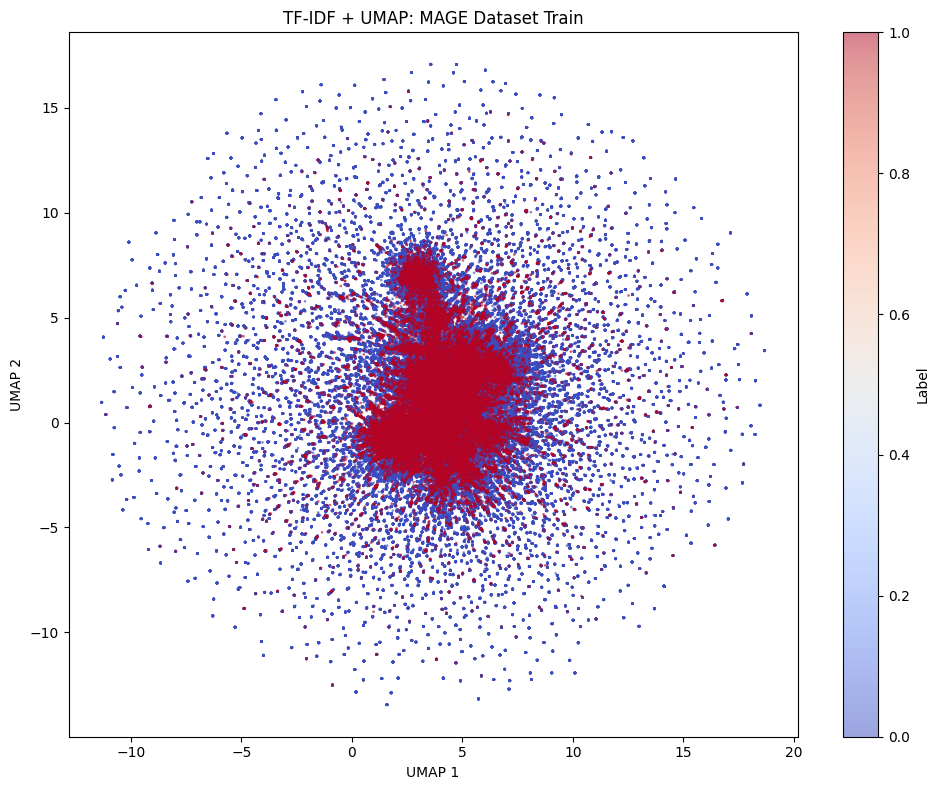

In [ ]:
df_mage_train_sampled = df_mage_train.sample(n=10000, seed=RANDOM_STATE)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_mage_train['text'])

umap = UMAP(
    n_components=2,
    n_neighbors=15,
)

umap_embedded = umap.fit_transform(tfidf_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedded[:, 0], 
    umap_embedded[:, 1], 
    c=df_mage_train['label'],
    cmap='coolwarm',
    alpha=0.5,
    s=1
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'TF-IDF + UMAP: MAGE Dataset Train')
plt.colorbar(scatter, label='Label')
plt.tight_layout()
plt.show()

In [ ]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

def get_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        
        # Токенизация с явным ограничением длины
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        cls_embeddings = outputs.pooler_output
        
        embeddings.extend(cls_embeddings)
    
    return np.array(embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [148]:
n_samples = 5000
df_sample = df_mage_train.sample(n=n_samples, seed=RANDOM_STATE)

texts = df_sample['text'].to_list()
bert_embeddings = get_embeddings(texts)

  0%|          | 0/157 [00:00<?, ?it/s]

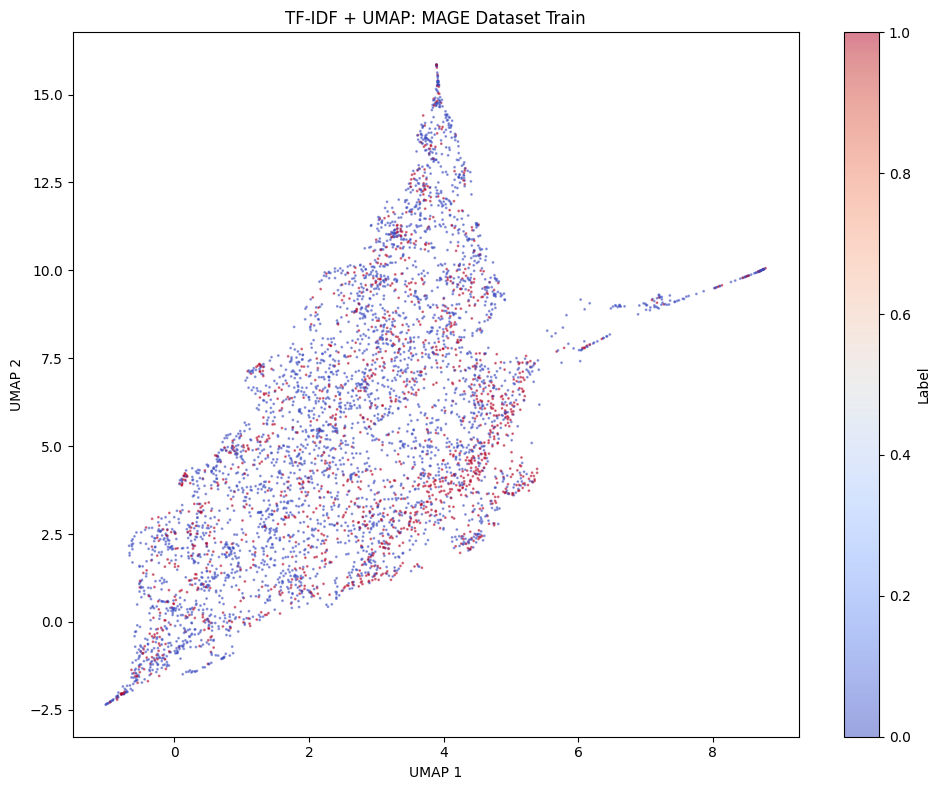

In [149]:
umap = UMAP(
    n_components=2,
    n_neighbors=15,
)

umap_embedded = umap.fit_transform(bert_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_embedded[:, 0], 
    umap_embedded[:, 1], 
    c=df_sample['label'],
    cmap='coolwarm',
    alpha=0.5,
    s=1
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'TF-IDF + UMAP: MAGE Dataset Train')
plt.colorbar(scatter, label='Label')
plt.tight_layout()
plt.show()

In [6]:
ds = load_dataset("yaful/MAGE")

# Now 0 - machine-generated, 1 - human-written
# Replace to 1 - machine-generated, 0 - human-written for consistency
ds = ds.map(lambda x: {"label": 1 - x["label"]})

ds_mage_train = ds["train"]
ds_mage_val = ds["validation"]
ds_mage_test = ds["test"]

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/404M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/72.3M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/71.7M [00:00<?, ?B/s]

test_ood_set_gpt.csv: 0.00B [00:00, ?B/s]

...

Generating validation split:   0%|          | 0/56792 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/60743 [00:00<?, ? examples/s]

Map:   0%|          | 0/319071 [00:00<?, ? examples/s]

Map:   0%|          | 0/56792 [00:00<?, ? examples/s]

Map:   0%|          | 0/60743 [00:00<?, ? examples/s]

In [ ]:
# np.random.seed(RANDOM_STATE)

# indices = np.random.choice(range(ds_mage_train.num_rows), replace=False, size=SAMPLE_SIZE)

# ds_mage_train_sample = ds_mage_train.select(indices)

## M4GT-Bench

Paper: https://arxiv.org/pdf/2402.11175

GitHub: https://github.com/mbzuai-nlp/M4GT-Bench?tab=readme-ov-file

In [70]:
df_m4gt = pl.read_ndjson("M4GT-Bench/SubtaskA_multilingual.jsonl")

In [78]:
print(f"df length: {df_m4gt.shape[0]}")

df length: 218795


In [71]:
df_m4gt.head()

text,label,model,source,id
str,i64,str,str,f64
"""Forza Motorsport is a popular …",1,"""chatGPT""","""wikihow""",0.0
"""Buying Virtual Console games f…",1,"""chatGPT""","""wikihow""",1.0
"""Windows NT 4.0 was a popular o…",1,"""chatGPT""","""wikihow""",2.0
"""How to Make Perfume Perfume i…",1,"""chatGPT""","""wikihow""",3.0
"""How to Convert Song Lyrics to …",1,"""chatGPT""","""wikihow""",4.0


In [97]:
df_m4gt

text,label,model,source,id
str,i64,str,str,f64
"""Forza Motorsport is a popular …",1,"""chatGPT""","""wikihow""",0.0
"""Buying Virtual Console games f…",1,"""chatGPT""","""wikihow""",1.0
"""Windows NT 4.0 was a popular o…",1,"""chatGPT""","""wikihow""",2.0
"""How to Make Perfume Perfume i…",1,"""chatGPT""","""wikihow""",3.0
"""How to Convert Song Lyrics to …",1,"""chatGPT""","""wikihow""",4.0
…,…,…,…,…
"""Have you ever thought about pu…",0,"""human""","""outfox""",null
"""Cars are most the most used ma…",0,"""human""","""outfox""",null
"""In the article ""Making Mona Li…",0,"""human""","""outfox""",null


In [72]:
df_m4gt.group_by("source").agg(pl.len().alias("count")).sort(by="count", descending=True)

source,count
str,u32
"""reddit""",30999
"""wikihow""",30999
"""arxiv""",30997
"""wikipedia""",29029
"""outfox""",28200
…,…
"""italian""",6075
"""indonesian""",5995
"""urdu""",5899


In [82]:
df_m4gt.group_by("model").agg(pl.len().alias("count")).sort(by="count", descending=True)

model,count
str,u32
"""human""",99046
"""chatGPT""",38656
"""davinci""",23807
"""bloomz""",17332
"""dolly""",17046
"""cohere""",16678
"""llama2-fine-tuned""",6075
"""jais-30b""",155


In [93]:
df_m4gt.group_by("label").agg(pl.len().alias("count")).sort(by="count", descending=True)

label,count
i64,u32
1,112711
0,106084


In [103]:
# train/val split 

df_m4gt = df_m4gt.sample(fraction=1, shuffle=True)
val_size = df_m4gt.shape[0] // 5
df_m4gt_val, df_m4gt_train = df_m4gt.head(val_size), df_m4gt.tail(-val_size)

In [104]:
# Convert to Dataset
df_m4gt_train = Dataset.from_polars(df_m4gt_train)
df_m4gt_val = Dataset.from_polars(df_m4gt_val)

## Обучающий датасет 

Объединяем все датасеты в один

In [5]:
SAMPLE_SIZE=100

In [6]:
def sample_balanced_dataset(ds: Dataset, n_samples: int = None, random_state: int = RANDOM_STATE):
    np.random.seed(random_state)
    
    ds_class_0 = ds.filter(lambda x: x["label"] == 0)
    ds_class_1 = ds.filter(lambda x: x["label"] == 1)
    
    max_samples_per_class = min(len(ds_class_0), len(ds_class_1))
    
    if n_samples is not None:
        samples_per_class = min(n_samples // 2, max_samples_per_class)
    else:
        samples_per_class = max_samples_per_class
    
    indices_0 = np.random.choice(len(ds_class_0), size=samples_per_class, replace=False)
    indices_1 = np.random.choice(len(ds_class_1), size=samples_per_class, replace=False)
    
    ds_sample_0 = ds_class_0.select(indices_0)
    ds_sample_1 = ds_class_1.select(indices_1)
    
    ds_balanced = concatenate_datasets([ds_sample_0, ds_sample_1])
    ds_balanced = ds_balanced.shuffle(seed=random_state)
    
    return ds_balanced

In [7]:
ds_ruatd_train_sample = sample_balanced_dataset(ds_ruatd_train, SAMPLE_SIZE)
# ds_mgt_multi_train_sample = sample_balanced_dataset(ds_mgt_multi_train, SAMPLE_SIZE)
# ds_mage_train_sample = sample_balanced_dataset(ds_mage_train, SAMPLE_SIZE)

In [8]:
ds_train_final = concatenate_datasets([
    ds_ruatd_train_sample.remove_columns([c for c in ds_ruatd_train_sample.column_names if c not in ['text', 'label']]),
    # ds_mgt_multi_train_sample.remove_columns([c for c in ds_mgt_multi_train_sample.column_names if c not in ['text', 'label']]),
    # ds_mage_train_sample.remove_columns([c for c in ds_mage_train_sample.column_names if c not in ['text', 'label']])
]).shuffle(seed=RANDOM_STATE)

In [9]:
ds_train_final

Dataset({
    features: ['text', 'label'],
    num_rows: 100
})

In [10]:
ds_ruatd_val_sample = sample_balanced_dataset(ds_ruatd_val, SAMPLE_SIZE)
# ds_mgt_multi_val_sample = sample_balanced_dataset(ds_mgt_multi_val, SAMPLE_SIZE)
# ds_mage_val_sample = sample_balanced_dataset(ds_mage_val, SAMPLE_SIZE)

In [11]:
ds_val_final = concatenate_datasets([
    ds_ruatd_val_sample.remove_columns([c for c in ds_ruatd_val_sample.column_names if c not in ['text', 'label']]),
    # ds_mgt_multi_val_sample.remove_columns([c for c in ds_mgt_multi_val_sample.column_names if c not in ['text', 'label']]),
    # ds_mage_val_sample.remove_columns([c for c in ds_mage_val_sample.column_names if c not in ['text', 'label']])
]).shuffle(seed=RANDOM_STATE)

In [12]:
ds_val_final

Dataset({
    features: ['text', 'label'],
    num_rows: 100
})

# Обучение моделей

## BERT

In [13]:
# base_model = "google-bert/bert-base-multilingual-cased"
base_model = "microsoft/mdeberta-v3-base"
# base_model = "FacebookAI/roberta-base"
# base_model = "ai-forever/ruBert-base"

In [14]:
tokenizer = AutoTokenizer.from_pretrained(base_model)

In [15]:
train_tokenized = ds_train_final.map(lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=512), batched=True, remove_columns=["text"])
valid_tokenized = ds_val_final.map(lambda x: tokenizer(x["text"], truncation=True, padding="max_length", max_length=512), batched=True, remove_columns=["text"])

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [16]:
collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
train_dataloader = DataLoader(train_tokenized, shuffle=True, batch_size=4, collate_fn=collator)
val_dataloader = DataLoader(valid_tokenized, shuffle=False, batch_size=4, collate_fn=collator)

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(base_model, num_labels=2)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                

In [19]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

model.to(device)

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [ ]:
optimizer = AdamW(
    model.parameters(), 
    lr=5e-5,
    weight_decay=0.01,
)

In [ ]:
from transformers import get_constant_schedule_with_warmup

num_epochs = 3

scheduler = get_constant_schedule_with_warmup(
    optimizer,
    num_warmup_steps=50,
)

In [ ]:
# num_epochs = 3

losses = []
for epoch in trange(num_epochs):
    pbar = tqdm(train_dataloader)
    model.train()
    for batch in pbar:
        out = model(**batch.to(device))
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        losses.append(out.loss.item())
        pbar.set_description(f'loss: {np.mean(losses[-100:]):2.2f}')
    model.eval()
    eval_losses = []
    eval_preds = []
    eval_targets = []
    for batch in tqdm(val_dataloader):
        with torch.no_grad():
            out = model(**batch.to(device))
        eval_losses.append(out.loss.item())
        eval_preds.extend(out.logits.argmax(1).tolist())
        eval_targets.extend(batch['labels'].tolist())
    print('recent train loss', np.mean(losses[-100:]), 'eval loss', np.mean(eval_losses), 'accuracy', np.mean(np.array(eval_targets) == eval_preds))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Сохраняем модель и оптимизатор

In [66]:
save_directory = "./bert_base_multilingual_fine_tuned"

model.save_pretrained(save_directory)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [68]:
!zip -r bert_base_multilingual_fine_tuned.zip bert_base_multilingual_fine_tuned
!cp bert_base_multilingual_fine_tuned.zip '/content/drive/My Drive/Downloads'
!ls -lt '/content/drive/My Drive/Downloads/'

  adding: bert_base_multilingual_fine_tuned/ (stored 0%)
  adding: bert_base_multilingual_fine_tuned/model.safetensors (deflated 7%)
  adding: bert_base_multilingual_fine_tuned/config.json (deflated 56%)
total 644231
-rw------- 1 root root 659692383 Mar  9 20:39 bert_base_multilingual_fine_tuned.zip


In [69]:
PATH = 'optimizer_bert_base_multilingual_fine_tuned.pth'
torch.save(optimizer.state_dict(), PATH)

In [77]:
!zip -r optimizer_bert_base_multilingual_fine_tuned.zip optimizer_bert_base_multilingual_fine_tuned.pth
!cp optimizer_bert_base_multilingual_fine_tuned.zip '/content/drive/My Drive/Downloads'

updating: optimizer_bert_base_multilingual_fine_tuned.pth (deflated 40%)


In [6]:
# from google.colab import drive
# drive.flush_and_unmount()

In [7]:
# model = AutoModelForSequenceClassification.from_pretrained(save_directory)

Проверяем работу модели

In [ ]:
model.eval()

In [75]:
def classify(text):
    with torch.no_grad():
        proba = torch.softmax(model(**tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to(device)).logits, -1)
    return proba.cpu().numpy()[0]

In [ ]:
# Qwen3.5-Plus, промпт: "Напиши несколько предложений о капибаре, которая работает астрофизиком"
sample_string = "В высокой обсерватории работает самая невозмутимая астрофизик в мире — капибара по имени Космо. " \
"Она изучает рождение звёзд через мощный телескоп, периодически отвлекаясь, чтобы пожевать сочную траву или принять расслабляющую ванну прямо среди чертежей. " \
"Её коллеги уверяют, что именно благодаря её невероятному дзену ей удаётся решать сложнейшие уравнения чёрных дыр без лишней суеты."

classify(sample_string)

array([0.39051765, 0.60948235], dtype=float32)

Оценка качества работы модели на датасетах

RuATD

In [80]:
ruatd_val_tokenized = ds_ruatd_val.map(lambda x: tokenizer(x["text"], truncation=True, max_length=512), batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)
ruatd_val_dataloader = DataLoader(ruatd_val_tokenized, shuffle=False, batch_size=4, collate_fn=collator)

Map:   0%|          | 0/24628 [00:00<?, ? examples/s]

In [ ]:
model.eval()

eval_preds = []
eval_targets = []

for batch in tqdm(ruatd_val_dataloader):
    with torch.no_grad():
        out = model(**batch.to(device))

    eval_preds.extend(out.logits.argmax(1).tolist())
    eval_targets.extend(batch['labels'].tolist())

  0%|          | 0/6157 [00:00<?, ?it/s]

In [87]:
ruatd_accuracy = np.mean(np.array(eval_targets) == eval_preds)

In [88]:
print(f"RuATD Accuracy: {ruatd_accuracy}")

RuATD Accuracy: 0.5


MGT-1 Multi 

In [103]:
mgt_multi_val_tokenized = ds_mgt_multi_val.map(lambda x: tokenizer(x["text"], truncation=True, padding=True, max_length=512), batched=True, remove_columns=["id", "source", "sub_source", "lang", "text", "model"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)
mgt_multi_dataloader = DataLoader(mgt_multi_val_tokenized, shuffle=False, batch_size=4, collate_fn=collator)

Map:   0%|          | 0/288894 [00:00<?, ? examples/s]

In [104]:
model.eval()

eval_preds = []
eval_targets = []

for batch in tqdm(mgt_multi_dataloader):
    with torch.no_grad():
        out = model(**batch.to(device))

    eval_preds.extend(out.logits.argmax(1).tolist())
    eval_targets.extend(batch['labels'].tolist())

  0%|          | 0/72224 [00:00<?, ?it/s]

: 

: 

## LLM fine-tune (LoRA)

In [ ]:
# device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
# device

'mps'

In [8]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [18]:
train_dataset[0]["text"]

'Отношения Гапона с эсерами также порвались в сентябре 1905 года на почве соперничества за влияние на рабочие массы.'

In [ ]:
def preprocess_function(example):
    messages = example["messages"]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return tokenizer(prompt, truncation=True, padding="max_length", max_length=512)

In [ ]:
train_dataset.map(lambda x: tokenizer(x['text'], truncation=True, max_length=512), batched=True, remove_columns=['text'])

In [ ]:
# Tokenize data using chat template
def preprocess_function(example):
    messages = example["messages"]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return tokenizer(prompt, truncation=True, padding="max_length", max_length=512)

tokenized_train_dataset = train_dataset.map(preprocess_function, batched=False)
tokenized_eval_dataset = eval_dataset.map(preprocess_function, batched=False)

# Define LoRA config
lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

# Training arguments
training_args = TrainingArguments(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=16,
    warmup_steps=50,
    max_steps=200,
    learning_rate=5e-5,
    logging_steps=10,
    output_dir="./qwen2.5-0.5b-finetuned",
    logging_dir="./logs"
)

# Fine-tune using SFTTrainer
trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    peft_config=lora_config,
    args=training_args,
)

trainer.train()

# Save adapter weights (LoRA)
trainer.model.save_pretrained("./qwen2.5-0.5b-finetuned")

# Save tokenizer
tokenizer.save_pretrained("./qwen2.5-0.5b-finetuned")